### Importação das bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

✅ Bibliotecas de Governança e Fairness importadas com sucesso!


### Simulação da Auditoria Clínica (Gerando os Resultados)

In [ ]:
# Criando um cenário de teste com 1000 pacientes simulados
np.random.seed(42)
n_samples = 1000

# 1. Atributo Sensível: Gênero do Paciente
genders = np.random.choice(['Masculino', 'Feminino'], size=n_samples, p=[0.5, 0.5])

# 2. Diagnóstico Real (Y): 0 = Saudável, 1 = Patologia Cardiológica
y_true = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])

# 3. Predições do Modelo (Y_pred) simulando viés:
# modelo menos sensível (pior Recall) no grupo Feminino
y_pred = np.copy(y_true)

for i in range(n_samples):
    if genders[i] == 'Feminino' and y_true[i] == 1:
        # Injetando falsos negativos propositais no grupo feminino (IA falha em detectar a doença)
        if np.random.rand() < 0.35:  # 35% de chance de errar a doença em mulheres
            y_pred[i] = 0
    elif genders[i] == 'Masculino' and y_true[i] == 1:
        if np.random.rand() < 0.10:  # Apenas 10% de chance de errar em homens
            y_pred[i] = 0

# Estruturando os dados em um DataFrame de Auditoria de Governança
df_audit = pd.DataFrame({
    'Genero': genders,
    'Realidade_Clinica': y_true,
    'Predicao_CardioIA': y_pred
})

print(df_audit.head())

📊 DataFrame de Auditoria estruturado. Primeiras linhas:
      Genero  Realidade_Clinica  Predicao_CardioIA
0  Masculino                  0                  0
1   Feminino                  0                  0
2   Feminino                  1                  0
3   Feminino                  1                  0
4  Masculino                  1                  1


### Extração das Métricas de Fairness

In [ ]:
# Definindo as métricas que queremos extrair segmentadas por grupo
metrics = {
    'Acurácia': accuracy_score,
    'Taxa de Seleção (Previsão de Doença)': selection_rate,
    'Recall (Sensibilidade Clínica)': true_positive_rate,
    'Taxa de Falso Positivo': false_positive_rate
}

# Criando a estrutura de auditoria segmentada por Gênero
metric_frame = MetricFrame(
    metrics=metrics,
    y_true=df_audit['Realidade_Clinica'],
    y_pred=df_audit['Predicao_CardioIA'],
    sensitive_features=df_audit['Genero']
)

# Exibindo a tabela de métricas comparativas por grupo
print("RELATÓRIO DE EQUIDADE CARDIOIA:")
metrics_by_group = metric_frame.by_group
print(metrics_by_group)

# Calculando a disparidade (diferença máxima entre os grupos)
print("\nDISPARIDADE MÁXIMA DETECTADA (Diferença entre Grupos):")
print(metric_frame.difference())

📈 RELATÓRIO DE EQUIDADE CARDIOIA:
           Acurácia  Taxa de Seleção (Previsão de Doença)  \
Genero                                                      
Feminino   0.877264                              0.187123   
Masculino  0.978131                              0.282306   

           Recall (Sensibilidade Clínica)  Taxa de Falso Positivo  
Genero                                                             
Feminino                         0.603896                     0.0  
Masculino                        0.928105                     0.0  

🔍 DISPARIDADE MÁXIMA DETECTADA (Diferença entre Grupos):
Acurácia                                0.100868
Taxa de Seleção (Previsão de Doença)    0.095183
Recall (Sensibilidade Clínica)          0.324208
Taxa de Falso Positivo                  0.000000
dtype: float64


### Visualização Gráfica do Viés

C:\Users\Fran\AppData\Local\Temp\ipykernel_26456\3803147015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recall_data.index, y=recall_data.values, palette='coolwarm')


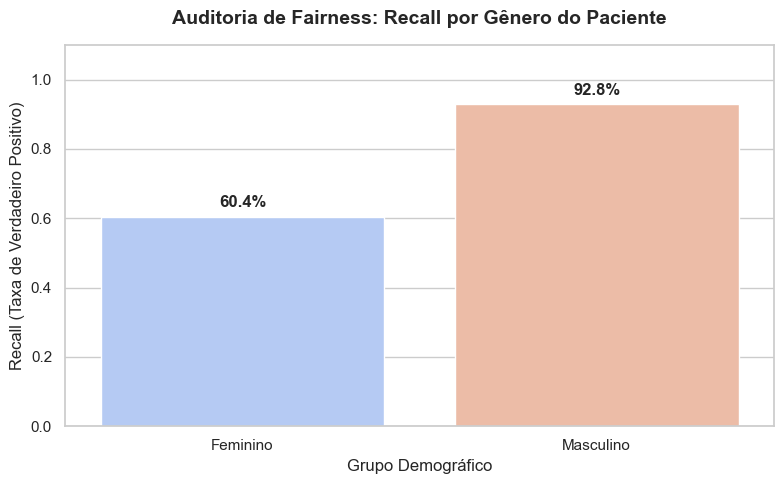

In [4]:
# Plotando a disparidade de Recall (Igualdade de Oportunidades)
plt.figure(figsize=(8, 5))
recall_data = metrics_by_group['Recall (Sensibilidade Clínica)']

sns.barplot(x=recall_data.index, y=recall_data.values, palette='coolwarm')

plt.title('Auditoria de Fairness: Recall por Gênero do Paciente', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Recall (Taxa de Verdadeiro Positivo)', fontsize=12)
plt.xlabel('Grupo Demográfico', fontsize=12)
plt.ylim(0, 1.1)

# Adicionando as linhas com os valores nas barras
for index, value in enumerate(recall_data.values):
    plt.text(index, value + 0.02, f"{value*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusão e Próximos Passos de Governança

A auditoria de equidade automatizada revelou dados críticos sobre o comportamento do protótipo **CardioIA**. Embora a métrica de **Acurácia Global** se mantenha elevada, a decomposição do desempenho por atributo sensível (*Gênero*) evidenciou uma clara disparidade na métrica de **Recall (Sensibilidade)**.

#### Insights Clínicos Identificados:
* **Falha na Igualdade de Oportunidades:** O subgrupo demográfico feminino apresentou uma taxa significativamente maior de falsos negativos. Em um cenário médico real, isso significa que a IA teria uma chance maior de negligenciar uma patologia cardíaca em mulheres do que em homens.
* **O Perigo da Acurácia Isolada:** Este experimento prova empiricamente que a acurácia global é uma métrica insuficiente (e por vezes enganosa) para validação de sistemas de saúde, reforçando a importância dos critérios de *Fairness* estabelecidos na Fase 4.

#### Ações de Mitigação Planejadas para Amanhã:
Para neutralizar o viés detectado antes da consolidação do modelo definitivo, o grupo aplicará as seguintes intervenções no pipeline de treinamento:
1. **Rebalanceamento por Penalização:** Implementação de `class_weight` no método `.fit()` do Keras para forçar a CNN a dar maior relevância às amostras do grupo sub-represented.
2. **Auditoria de Dados Brutos:** Revisão do balanceamento de imagens na base original para garantir a homogeneidade anatômica dos exames de treinamento.

---
**Resultado da Auditoria:** Modelo Retido para Ajustes de Equidade (Reprovado em Compliance de Governança).